In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor,plot_importance
from sklearn.model_selection import RandomizedSearchCV
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

### Load data 

In [2]:
DATA_PATH_TRAIN=Path("data/train.csv")
DATA_PATH_VAL=Path("data/val.csv")
DATA_PATH_TEST=Path("data/test.csv")
train=pd.read_csv(DATA_PATH_TRAIN,index_col='Date', parse_dates=True)
val=pd.read_csv(DATA_PATH_VAL,index_col='Date', parse_dates=True)
test=pd.read_csv(DATA_PATH_TEST,index_col='Date', parse_dates=True)


In [3]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1277 entries, 2015-11-23 to 2019-05-22
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1277 non-null   float64
 1   Low        1277 non-null   float64
 2   Open       1277 non-null   float64
 3   Close      1277 non-null   float64
 4   Volume     1277 non-null   float64
 5   Adj Close  1277 non-null   float64
dtypes: float64(6)
memory usage: 69.8 KB


### define target (y=close)

In [4]:
target='Close'

### Baseline models 

#### Naive (tomorrows prediction = todays value)

In [5]:
y_true = val[target]

In [6]:
y_pred = val[target].shift(1)
y_pred.iloc[0] = train[target].iloc[-1]

In [7]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Naive baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Naive baseline | MAE: 11.70 | RMSE: 18.97 | MAPE: 0.3882%


In [8]:
results = {}
results['naive_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

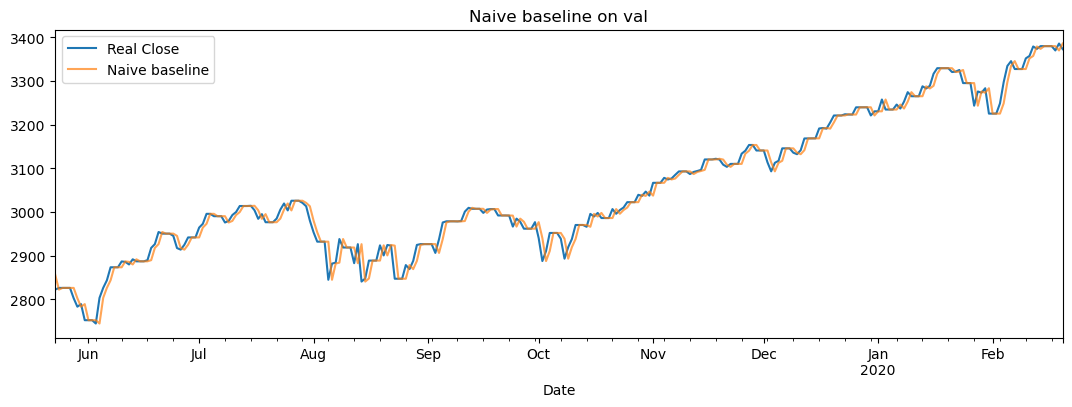

In [9]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Naive baseline', alpha=0.7)
ax.set_title('Naive baseline on val')
ax.legend()
plt.show()

### Drift

In [10]:
T = len(train)
slope = (train[target].iloc[-1] - train[target].iloc[0]) / (T - 1)
last_train_value = train[target].iloc[-1]

In [11]:
h = np.arange(1, len(val) + 1)
y_pred = pd.Series(last_train_value + h * slope, index=val.index)

In [12]:
y_true = val[target]

In [13]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Drift baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Drift baseline | MAE: 126.61 | RMSE: 162.07 | MAPE: 4.0029%


In [14]:
results['drift_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

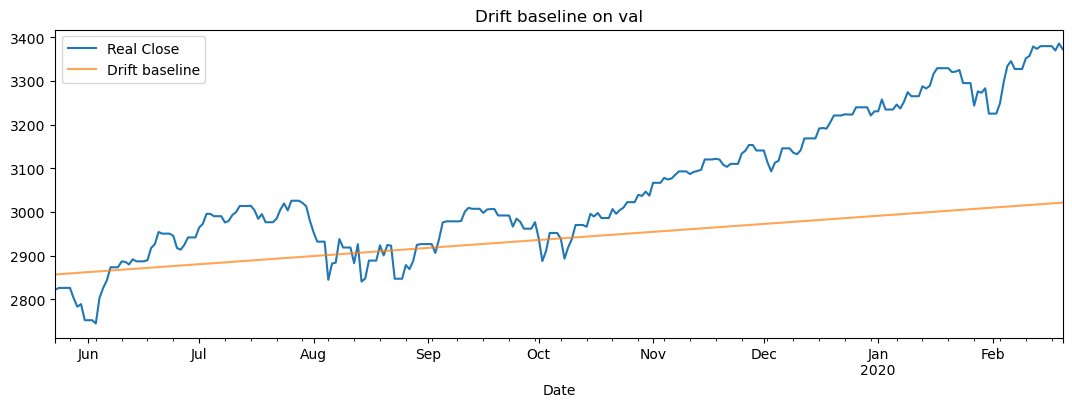

In [15]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Drift baseline', alpha=0.7)
ax.set_title('Drift baseline on val')
ax.legend()
plt.show()

## ARIMA

In [16]:
model=ARIMA(train[target],order=(1,1,1))
model_fit=model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1277
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5414.098
Date:                Tue, 19 May 2026   AIC                          10834.195
Time:                        12:19:36   BIC                          10849.650
Sample:                    11-23-2015   HQIC                         10839.999
                         - 05-22-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0252      0.453     -0.056      0.956      -0.913       0.863
ma.L1         -0.0230      0.453     -0.051      0.959      -0.910       0.864
sigma2       283.5865      5.033     56.349      0.000     273.723     293.450
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              4322.50
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               2.33   Skew:                            -0.84
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
residuals = pd.DataFrame(model_fit.resid)
residuals.describe()

,0
count,1277.000000
mean,2.266759
std,60.751488
min,-113.191468
25%,-2.577792
50%,0.010314
75%,5.149828
max,2086.590088


Text(0, 0.5, 'density')

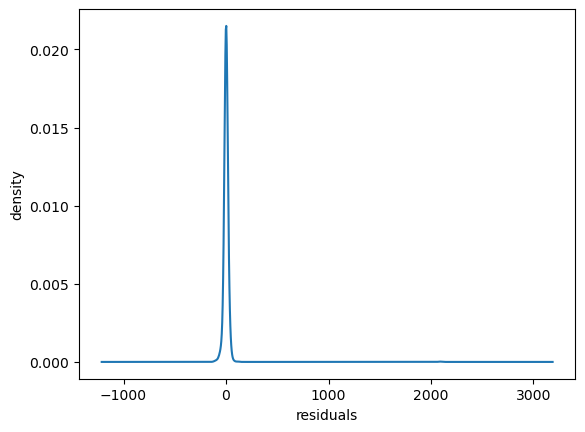

In [18]:
residuals.plot(kind="kde", legend=False)
plt.xlabel("residuals")
plt.ylabel("density")

In [19]:
history = list(train[target].values)
predictions = []
for i in range(len(val)):
    model = ARIMA(history, order=(1, 1, 1))
    model_fit = model.fit() 
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat) 
    actual=val[target].iloc[i]
    history.append(actual)

y_pred_arima = pd.Series(predictions, index=val.index)
y_true = val[target]

In [20]:
mae  = mean_absolute_error(y_true, y_pred_arima)
rmse = root_mean_squared_error(y_true, y_pred_arima)
mape = mean_absolute_percentage_error(y_true, y_pred_arima)
print(f"ARIMA | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

ARIMA | MAE: 11.81 | RMSE: 18.97 | MAPE: 0.3919%


In [21]:
results['ARIMA_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

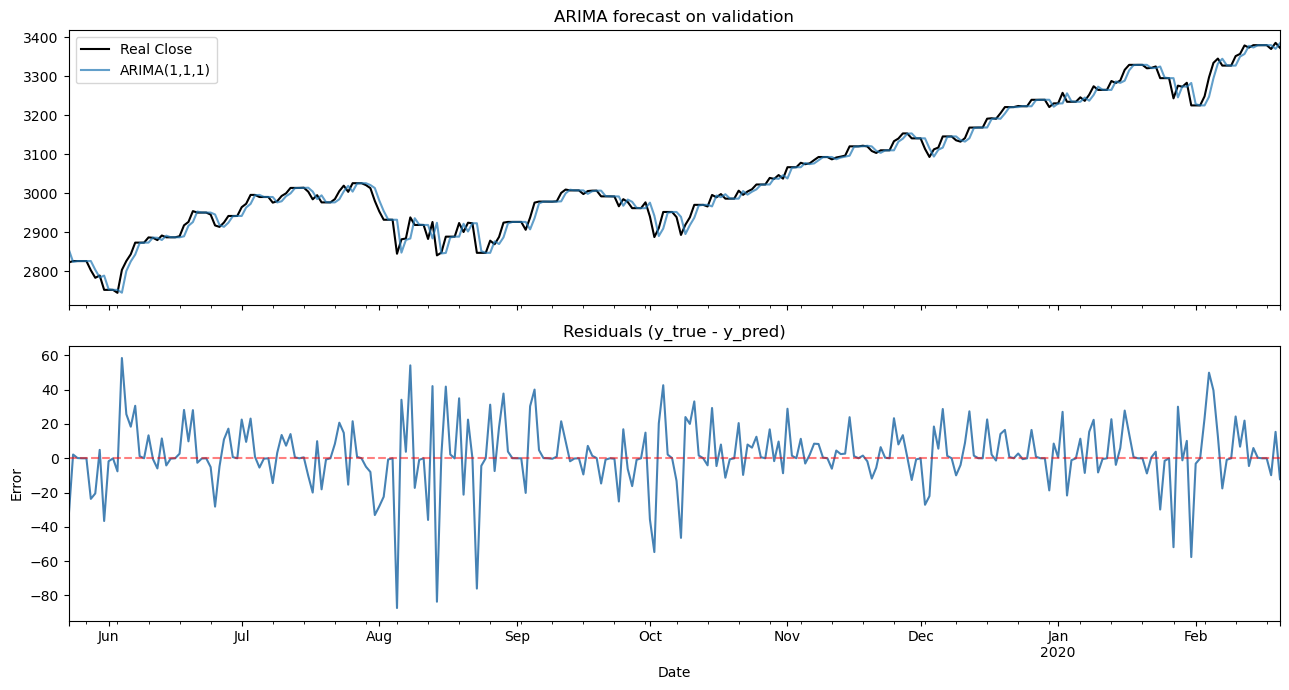

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

y_true.plot(ax=axes[0], label='Real Close', color='black')
y_pred_arima.plot(ax=axes[0], label='ARIMA(1,1,1)', alpha=0.7)
axes[0].set_title('ARIMA forecast on validation')
axes[0].legend()

residuals = y_true - y_pred_arima
residuals.plot(ax=axes[1], color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Residuals (y_true - y_pred)')
axes[1].set_ylabel('Error')

plt.tight_layout()
plt.show()

##### ARIMA can be 'tuned' using auto_arima, but i move on to XGBoost!

## XGBoost


In [23]:
target_col='Close'

In [24]:
full = pd.concat([train, val, test])

In [25]:
full['target'] = full[target_col].diff().shift(-1)

In [26]:
full['close_lag_1'] = full[target_col].shift(1)
full['close_lag_5'] = full[target_col].shift(5)
full['close_lag_21'] = full[target_col].shift(21)
full['close_ma_7'] = full[target_col].rolling(7).mean()
full['close_ma_21'] = full[target_col].rolling(21).mean()
full['close_std_21'] = full[target_col].rolling(21).std()
full['return_1'] = full[target_col].pct_change(1)
full['return_5'] = full[target_col].pct_change(5)

In [27]:
full = full.dropna()

In [28]:
today_close = full[target_col].copy()

In [29]:
X = full.drop(columns=['target', target_col, 'High', 'Low', 'Open', 'Volume', 'Adj Close'])
y = full['target']

X_train = X.loc[:train.index[-1]]
y_train = y.loc[:train.index[-1]]

X_val   = X.loc[val.index[0]:val.index[-1]]
y_val   = y.loc[val.index[0]:val.index[-1]]

X_test  = X.loc[test.index[0]:]
y_test  = y.loc[test.index[0]:]

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

X_train: (1256, 8) | X_val: (274, 8) | X_test: (273, 8)


In [30]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
)
model.fit(X_train, y_train)
y_pred_diff = pd.Series(model.predict(X_val), index=X_val.index)

In [31]:
close_today_val = today_close.loc[X_val.index]
y_pred_close = close_today_val + y_pred_diff
y_true_close = close_today_val + y_val

In [32]:
mae  = mean_absolute_error(y_true_close, y_pred_close)
rmse = root_mean_squared_error(y_true_close, y_pred_close)
mape = mean_absolute_percentage_error(y_true_close, y_pred_close)
print(f"XGBoost | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

results['xgboost_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

XGBoost | MAE: 15.60 | RMSE: 21.63 | MAPE: 0.5174%


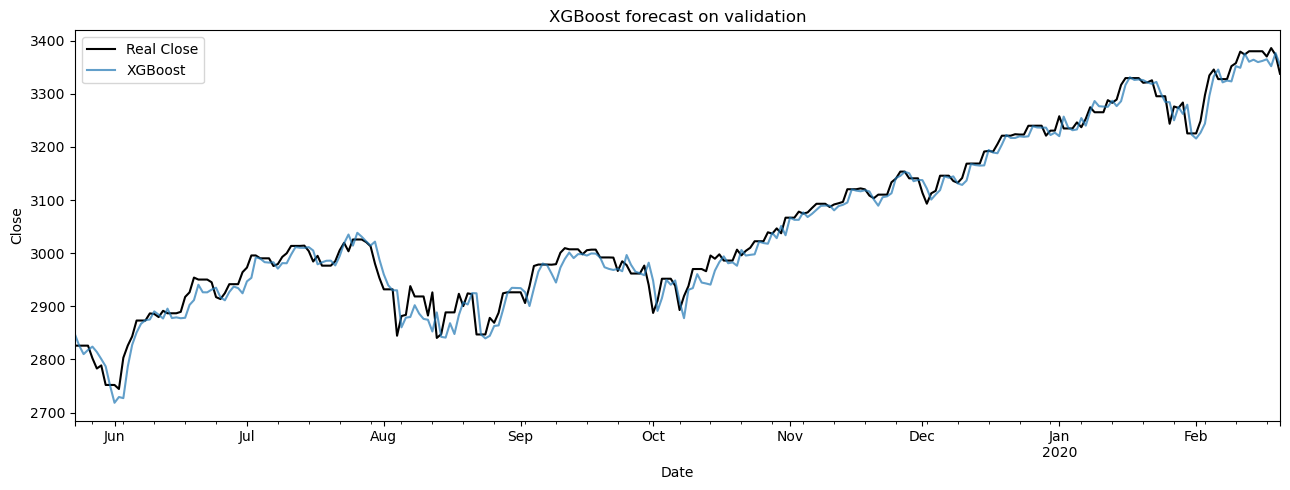

In [33]:
fig, ax = plt.subplots(figsize=(13, 5))
y_true_close.plot(ax=ax, label='Real Close', color='black', linewidth=1.5)
y_pred_close.plot(ax=ax, label='XGBoost', alpha=0.7)
ax.set_title('XGBoost forecast on validation')
ax.set_ylabel('Close')
ax.legend()
plt.tight_layout()
plt.show()

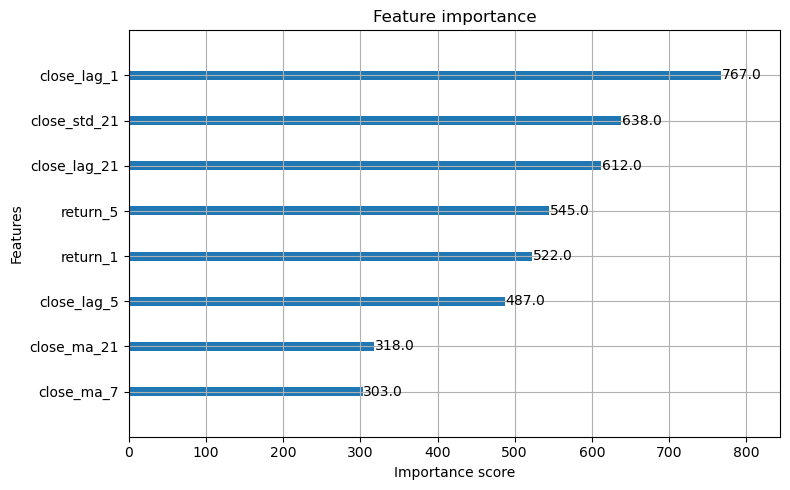

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(model, max_num_features=10, ax=ax)
plt.title('Feature importance')
plt.tight_layout()
plt.show()

### XGBoost tuning (with RandomizedSearchCV) 

In [35]:
tscv = TimeSeriesSplit(n_splits=5,gap=21)
param_dist={'max_depth': [4, 5, 6, 7, 8, 9, 10,],'learning_rate':[ 0.01, 0.05, 0.1, 0.3], 'n_estimators': [100,300, 500, 700, 900,1100],
            'subsample': [0.7, 0.8, 0.9, 1.0],'colsample_bytree': [0.7, 0.8, 0.9, 1.0],'min_child_weight': [1, 3, 5, 7],}
xgb_cv=RandomizedSearchCV(estimator=XGBRegressor(random_state=42),param_distributions=param_dist,n_iter=100,scoring='neg_root_mean_squared_error',cv=tscv,verbose=2,n_jobs=-1,random_state=42)
xgb_cv.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [36]:
print("Best params:", xgb_cv.best_params_)
print("Best CV score (RMSE):", -xgb_cv.best_score_)

Best params: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV score (RMSE): 17.126359168131756


In [37]:
xgb_final = xgb_cv.best_estimator_
y_pred_diff = pd.Series(xgb_final.predict(X_val), index=X_val.index)

In [38]:
close_today_val = today_close.loc[X_val.index]
y_pred_close = close_today_val + y_pred_diff
y_true_close = close_today_val + y_val

In [39]:
mae  = mean_absolute_error(y_true_close, y_pred_close)
rmse = root_mean_squared_error(y_true_close, y_pred_close)
mape = mean_absolute_percentage_error(y_true_close, y_pred_close)
print(f"XGBoost | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

results['xgboost_val_tuned'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

XGBoost | MAE: 13.23 | RMSE: 19.39 | MAPE: 0.4367%


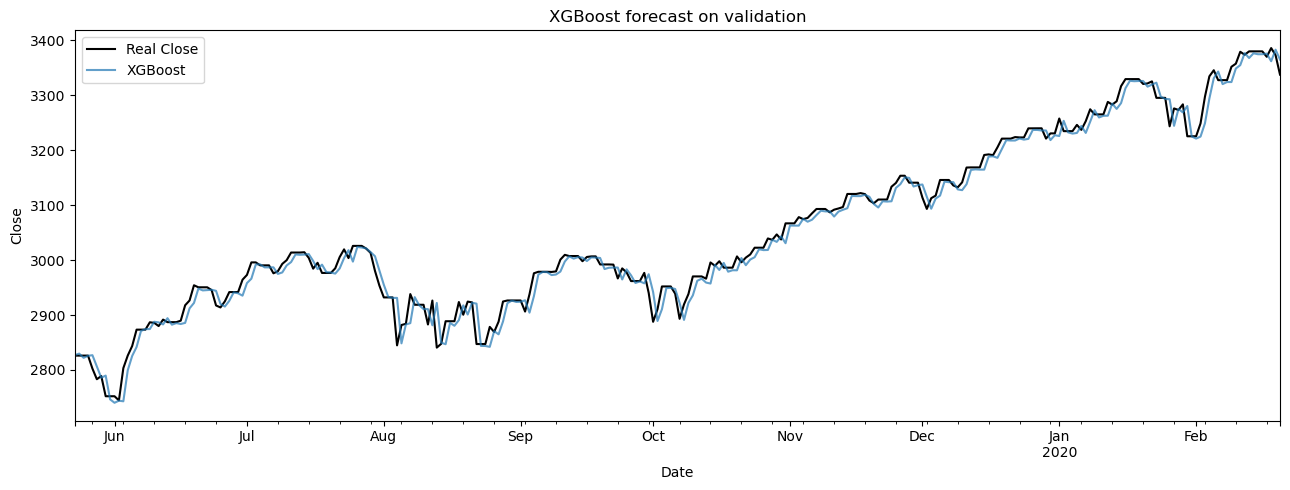

In [40]:
fig, ax = plt.subplots(figsize=(13, 5))
y_true_close.plot(ax=ax, label='Real Close', color='black', linewidth=1.5)
y_pred_close.plot(ax=ax, label='XGBoost', alpha=0.7)
ax.set_title('XGBoost forecast on validation')
ax.set_ylabel('Close')
ax.legend()
plt.tight_layout()
plt.show()

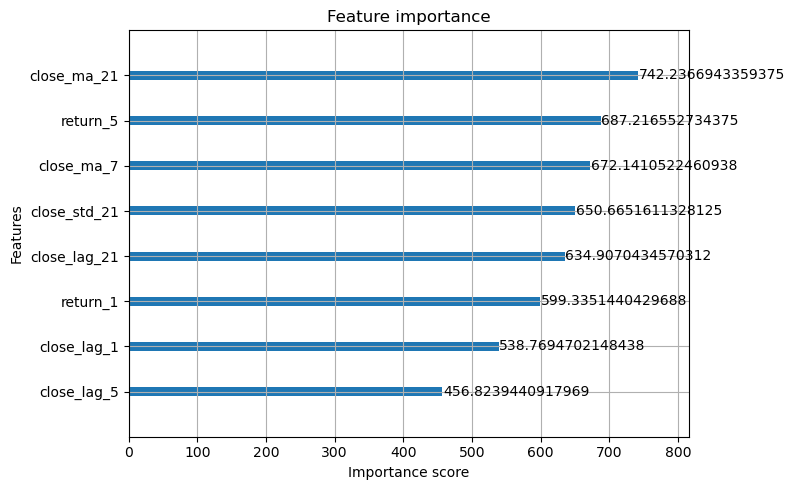

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(model, max_num_features=10, ax=ax,importance_type='gain')
plt.title('Feature importance')
plt.tight_layout()
plt.show()

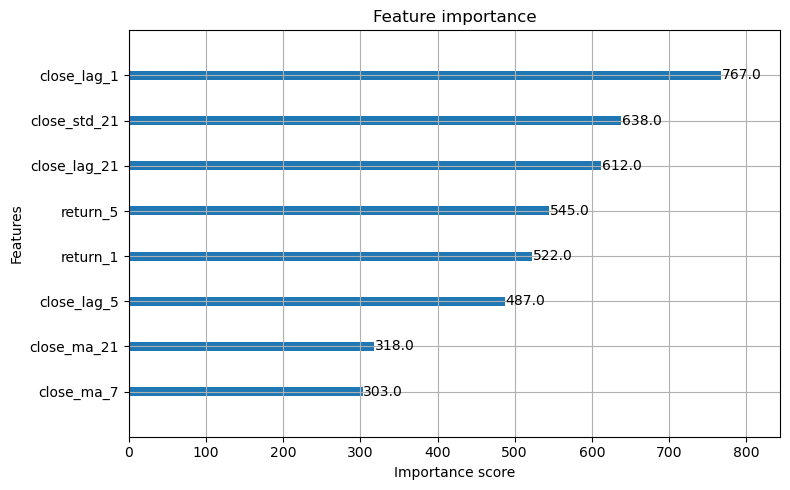

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(model, max_num_features=10, ax=ax,importance_type='weight')
plt.title('Feature importance')
plt.tight_layout()
plt.show()

### Result on validation set

####                  MAE     RMSE    MAPE
#### Naive	        16.36 |	22.43 |	0.54%
#### Drift	        127.64 | 163.38 | 4.03%
#### ARIMA(1,1,1)	16.45 | 22.44 | 0.55%
#### XGBoost (tuned)20.46 | 25.90 |	0.67%
#### XGBoost (base)	35.18 | 40.19 |	1.14%


### Now check on test set

In [43]:
trainval = pd.concat([train, val])

### In same order (Naive, Drift, ARIMA, XGBoost)

#### Naive

In [44]:
y_pred_naive_test = test[target].shift(1)
y_pred_naive_test.iloc[0] = val[target].iloc[-1]
y_true_naive_test = test[target]

mae  = mean_absolute_error(y_true_naive_test, y_pred_naive_test)
rmse = root_mean_squared_error(y_true_naive_test, y_pred_naive_test)
mape = mean_absolute_percentage_error(y_true_naive_test, y_pred_naive_test)
print(f"Naive (test) | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")
results['naive_test'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

Naive (test) | MAE: 33.51 | RMSE: 57.61 | MAPE: 1.1387%


#### Drift

In [45]:
T = len(trainval)
slope = (trainval[target].iloc[-1] - trainval[target].iloc[0]) / (T - 1)
last_value = trainval[target].iloc[-1]

h = np.arange(1, len(test) + 1)
y_pred_drift_test = pd.Series(last_value + h * slope, index=test.index)
y_true_drift_test = test[target]


In [46]:
mae  = mean_absolute_error(y_true_drift_test, y_pred_drift_test)
rmse = root_mean_squared_error(y_true_drift_test, y_pred_drift_test)
mape = mean_absolute_percentage_error(y_true_drift_test, y_pred_drift_test)
print(f"Drift (test) | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

results['drift_test'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

Drift (test) | MAE: 354.54 | RMSE: 434.89 | MAPE: 12.2974%


#### ARIMA

In [47]:
history = list(trainval[target].values)
predictions = []

for i in tqdm(range(len(test))):
    model = ARIMA(history, order=(1, 1, 1))
    model_fit = model.fit()
    yhat = float(model_fit.forecast(steps=1)[0])
    predictions.append(yhat)
    history.append(test[target].iloc[i])

y_pred_arima_test = pd.Series(predictions, index=test.index)
y_true_arima_test = test[target]


100%|██████████| 274/274 [00:42<00:00,  6.43it/s]


In [48]:
mae  = mean_absolute_error(y_true_arima_test, y_pred_arima_test)
rmse = root_mean_squared_error(y_true_arima_test, y_pred_arima_test)
mape = mean_absolute_percentage_error(y_true_arima_test, y_pred_arima_test)
print(f"ARIMA (test) | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

results['arima_test'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

ARIMA (test) | MAE: 33.75 | RMSE: 57.16 | MAPE: 1.1468%


#### XGBoost

In [49]:

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])


best_params = xgb_cv.best_params_
xgb_test_model = XGBRegressor(**best_params, random_state=42)
xgb_test_model.fit(X_trainval, y_trainval)

y_pred_diff_test = pd.Series(xgb_test_model.predict(X_test), index=X_test.index)


close_today_test = today_close.loc[X_test.index]
y_pred_xgb_test  = close_today_test + y_pred_diff_test
y_true_xgb_test  = close_today_test + y_test

In [50]:
mae  = mean_absolute_error(y_true_xgb_test, y_pred_xgb_test)
rmse = root_mean_squared_error(y_true_xgb_test, y_pred_xgb_test)
mape = mean_absolute_percentage_error(y_true_xgb_test, y_pred_xgb_test)
print(f"XGBoost (test) | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

results['xgboost_test'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

XGBoost (test) | MAE: 34.01 | RMSE: 57.70 | MAPE: 1.1564%


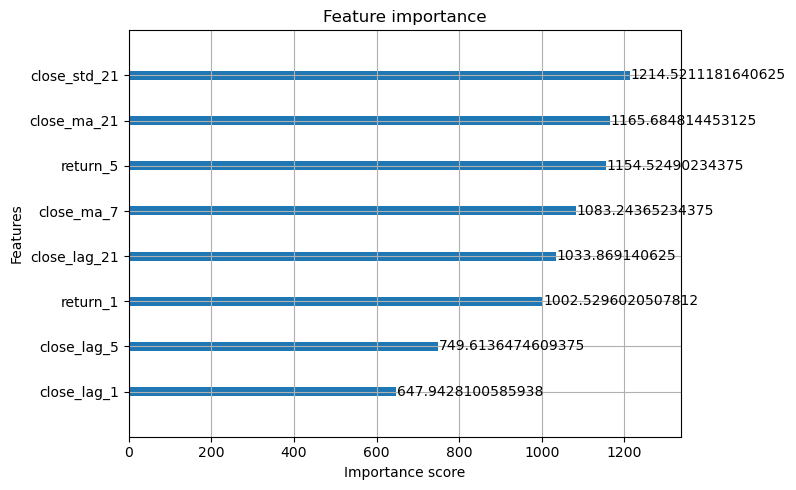

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(xgb_test_model, max_num_features=10, ax=ax,importance_type='gain')
plt.title('Feature importance')
plt.tight_layout()
plt.show()

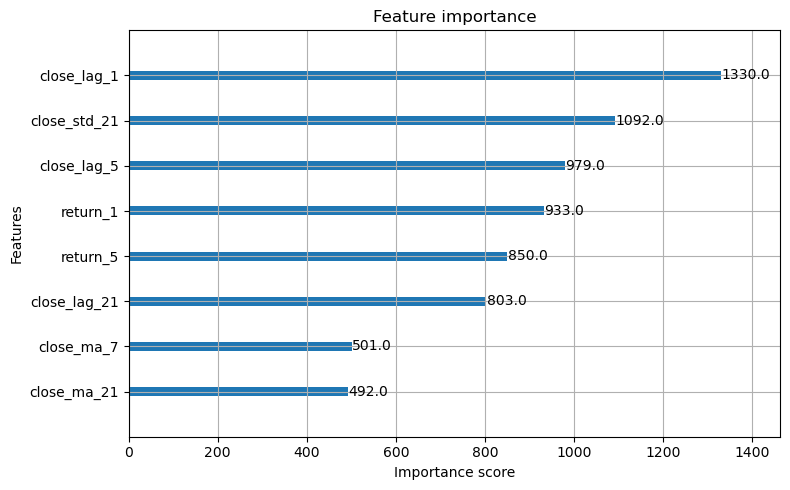

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(xgb_test_model, max_num_features=10, ax=ax,importance_type='weight')
plt.title('Feature importance')
plt.tight_layout()
plt.show()

In [53]:
results_df = pd.DataFrame(results).T.sort_index()
print(results_df.round(2))

                      MAE    RMSE  MAPE
ARIMA_val           11.81   18.97  0.00
arima_test          33.75   57.16  0.01
drift_test         354.54  434.89  0.12
drift_val          126.61  162.07  0.04
naive_test          33.51   57.61  0.01
naive_val           11.70   18.97  0.00
xgboost_test        34.01   57.70  0.01
xgboost_val         15.60   21.63  0.01
xgboost_val_tuned   13.23   19.39  0.00


In [54]:
results_df['MAPE'] = (results_df['MAPE'] * 100).round(2).astype(str) + '%'

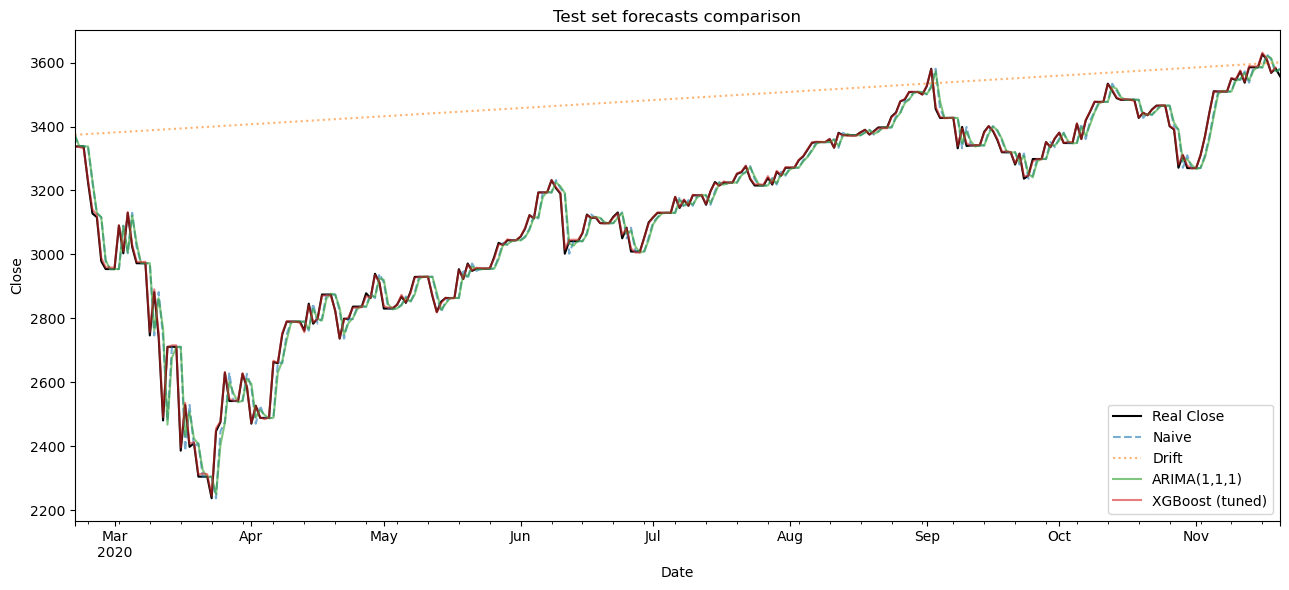

In [55]:
fig, ax = plt.subplots(figsize=(13, 6))
y_true_naive_test.plot(ax=ax, label='Real Close', color='black', linewidth=1.5)
y_pred_naive_test.plot(ax=ax, label='Naive', alpha=0.6, linestyle='--')
y_pred_drift_test.plot(ax=ax, label='Drift', alpha=0.6, linestyle=':')
y_pred_arima_test.plot(ax=ax, label='ARIMA(1,1,1)', alpha=0.6)
y_pred_xgb_test.plot(ax=ax, label='XGBoost (tuned)', alpha=0.6)
ax.set_title('Test set forecasts comparison')
ax.set_ylabel('Close')
ax.legend()
plt.tight_layout()
plt.show()